# Bank Churners — Exploratory Data Analysis

**Goal:** Understand data quality, churn rate, and variables associated with attrition.

*Observations* describe what we see in the data. *Hypotheses* are tentative explanations to test later — not causal claims.

In [1]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src" / "churn_config.py").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))

from churn_config import (
    BIVARIATE_CATEGORICAL,
    BIVARIATE_NUMERICAL,
    CATEGORICAL_COLUMNS,
    COLUMNS_WITH_UNKNOWN,
    ID_COLUMN,
    LEAKAGE_COLUMNS,
    NUMERICAL_COLUMNS,
    ORDINAL_COLUMNS,
    ORDINAL_MAPPINGS,
    NOMINAL_COLUMNS,
    TARGET_COLUMN,
    CHURN_COLUMN,
    FIGURES_DIR,
)
from data_io import churn_rate, load_raw_churners, quality_summary_table
import eda_viz
from eda_viz import (
    apply_plot_style,
    outlier_flags_iqr,
    plot_bivariate_categorical,
    plot_bivariate_numeric,
    plot_correlation_heatmap,
    plot_target_distribution,
    plot_univariate_categorical,
    plot_univariate_numeric,
    reset_figure_counter,
)

eda_viz.AUTO_CLOSE = False  # keep figures open for plt.show() in plotting cells

apply_plot_style()
reset_figure_counter(0)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("Figures will be saved to:", FIGURES_DIR.resolve())

Figures will be saved to: C:\Users\Windows\Documents\Repo Folder\bank-churners-cursor-bootcamp\reports\figures


## 1. Data Loading

In [2]:
df_full, df = load_raw_churners()
print(f"Rows: {len(df_full):,} | Columns (raw): {df_full.shape[1]}")
print(f"Churn rate: {churn_rate(df_full):.1%}")
display(df_full.head(3))
print("Leakage columns in file:", [c for c in LEAKAGE_COLUMNS if c in df_full.columns] or "none")
print("Analysis frame columns:", list(df.columns))

Rows: 10,127 | Columns (raw): 22
Churn rate: 16.1%


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,churn
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0


Leakage columns in file: none
Analysis frame columns: ['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'churn']


**Observation:** Each `CLIENTNUM` should be unique; leakage model outputs must stay out of feature analysis.

**Observation:** Overall churn rate is reported above; expect class imbalance for modeling.

In [3]:
dup_ids = df_full[ID_COLUMN].duplicated().sum()
dup_rows = df_full.duplicated().sum()
print(f"Duplicate {ID_COLUMN}: {dup_ids}")
print(f"Duplicate rows: {dup_rows}")

Duplicate CLIENTNUM: 0
Duplicate rows: 0


## 2. Data Quality

In [4]:
quality = quality_summary_table(df)
display(quality)

unknown_cols = {c: int((df[c].astype(str) == "Unknown").sum()) for c in COLUMNS_WITH_UNKNOWN if c in df.columns}
print("Unknown category counts:", unknown_cols)

,column,dtype,missing,unknown,n_unique
0,Attrition_Flag,object,0,0,2
1,Customer_Age,int64,0,0,45
2,Gender,object,0,0,2
3,Dependent_count,int64,0,0,6
4,Education_Level,object,0,1519,7
5,Marital_Status,object,0,749,4
6,Income_Category,object,0,1112,6
7,Card_Category,object,0,0,4
8,Months_on_book,int64,0,0,44
9,Total_Relationship_Count,int64,0,0,6


Unknown category counts: {'Education_Level': 1519, 'Income_Category': 1112, 'Marital_Status': 749}


In [5]:
outlier_summary = []
key_numeric = ["Credit_Limit", "Total_Trans_Amt", "Avg_Utilization_Ratio", "Total_Amt_Chng_Q4_Q1"]
for col in key_numeric:
    flags = outlier_flags_iqr(df, col)
    outlier_summary.append({"column": col, "outliers_iqr": int(flags.sum()), "pct": f"{flags.mean():.1%}"})
display(pd.DataFrame(outlier_summary))

,column,outliers_iqr,pct
0,Credit_Limit,984,9.7%
1,Total_Trans_Amt,896,8.8%
2,Avg_Utilization_Ratio,0,0.0%
3,Total_Amt_Chng_Q4_Q1,396,3.9%


**Observation:** Missing values and `"Unknown"` categories are summarized above (Unknown is not the same as null).

**Observation:** Tukey IQR flags highlight extreme values on spend and utilization; we document them but do not remove rows in EDA.

**Hypothesis:** Higher inactivity and contact counts may co-occur with churn (to test in modeling).

## 3. Univariate Analysis

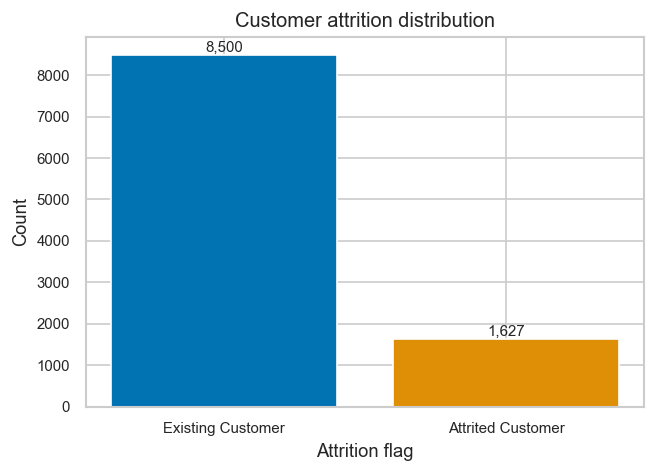

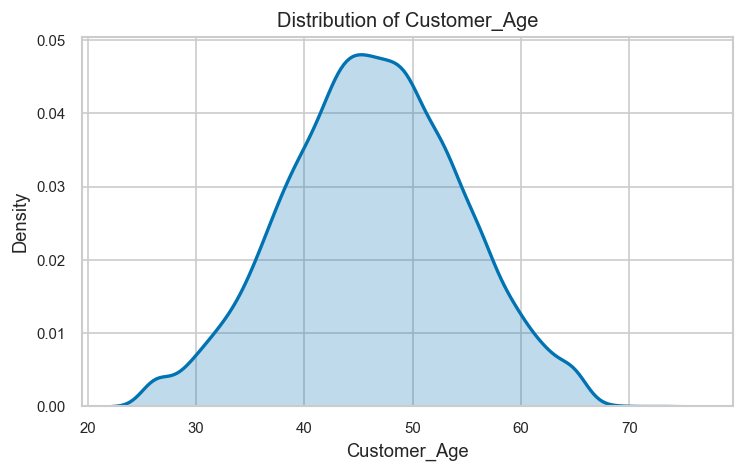

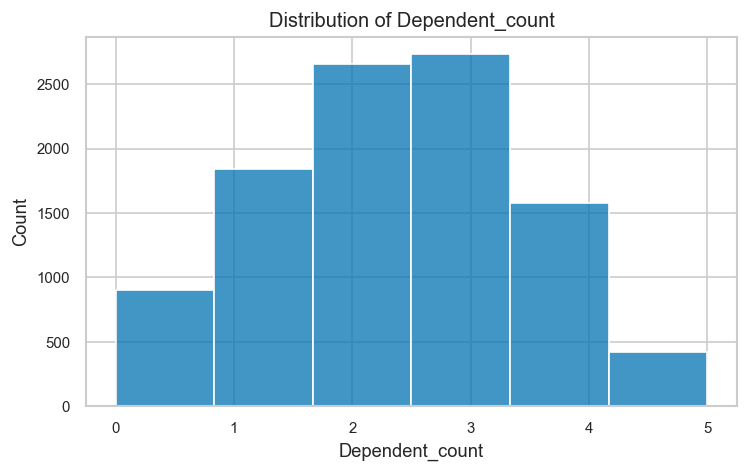

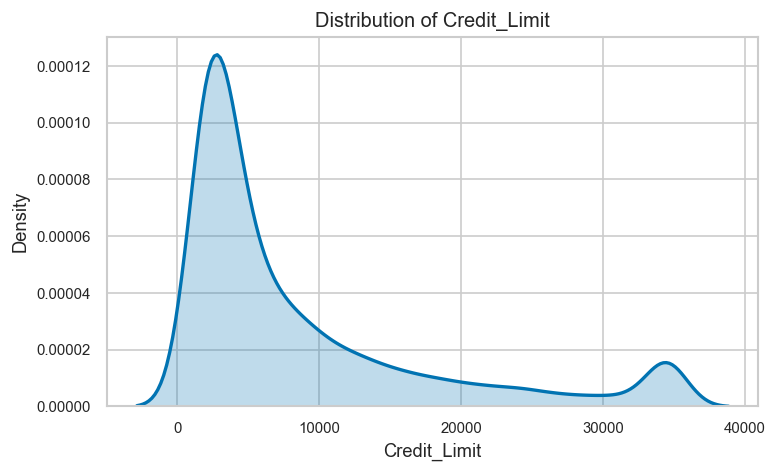

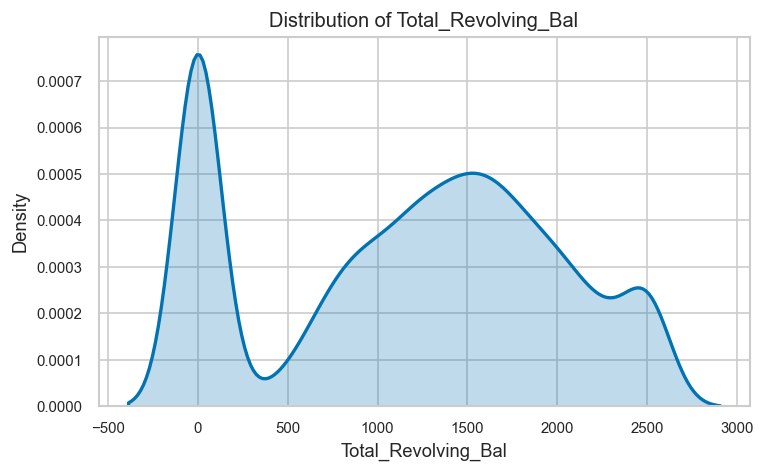

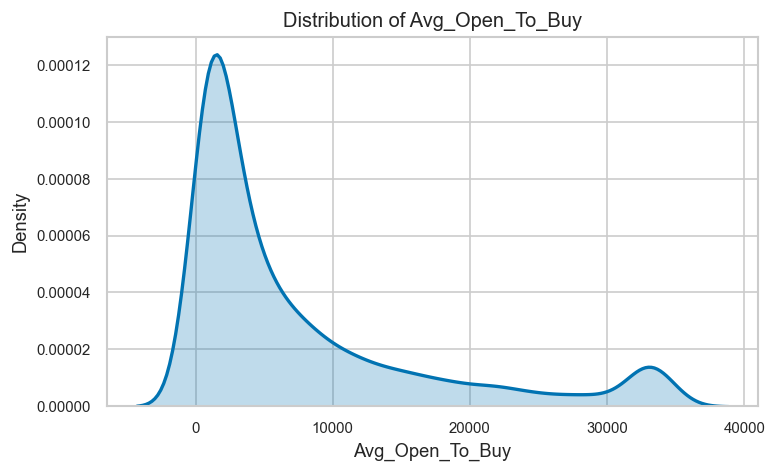

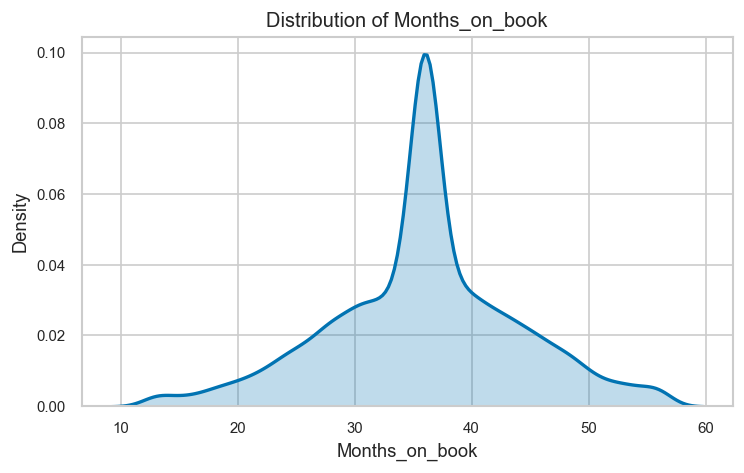

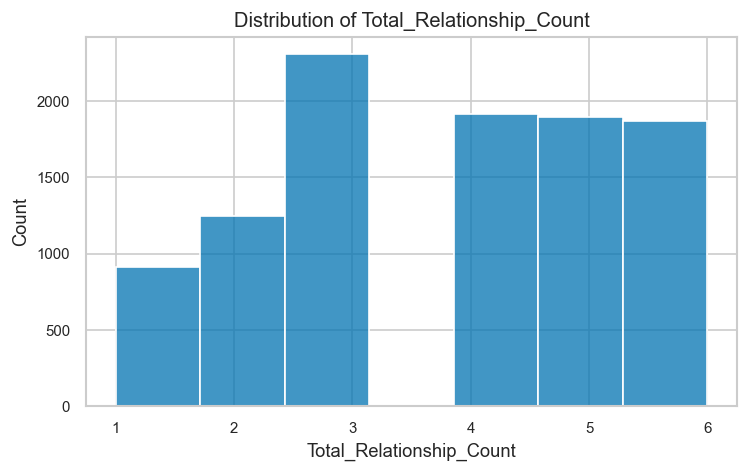

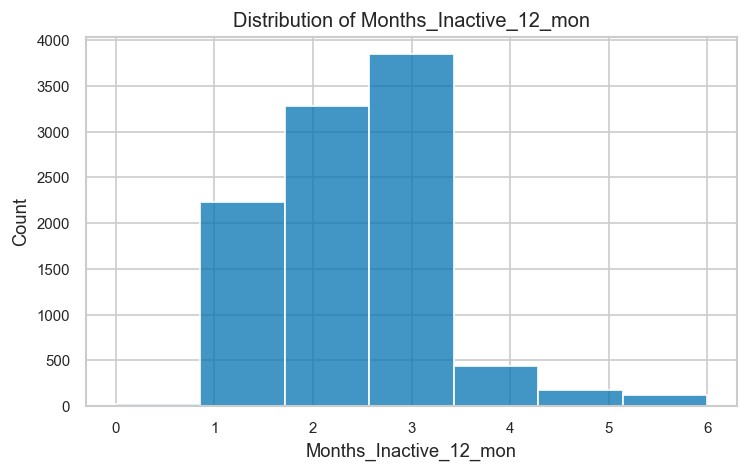

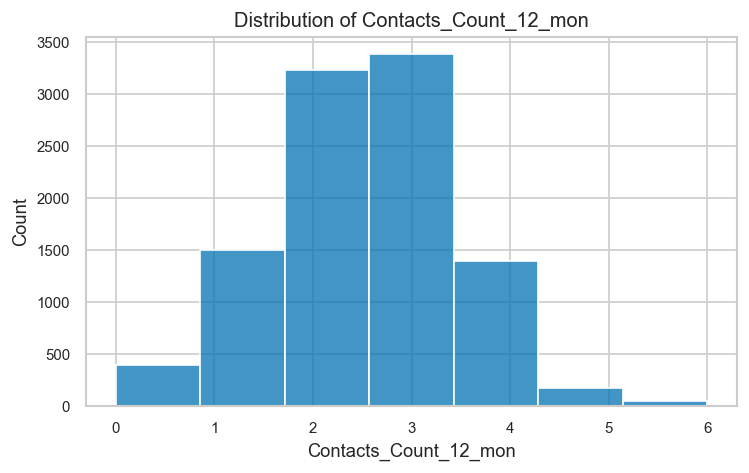

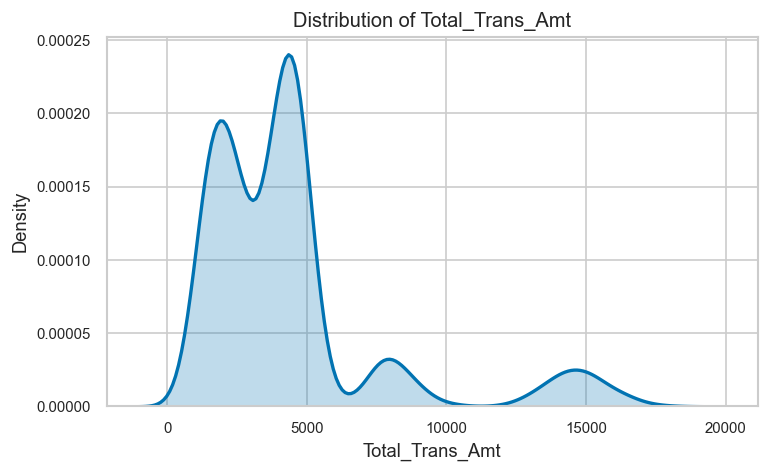

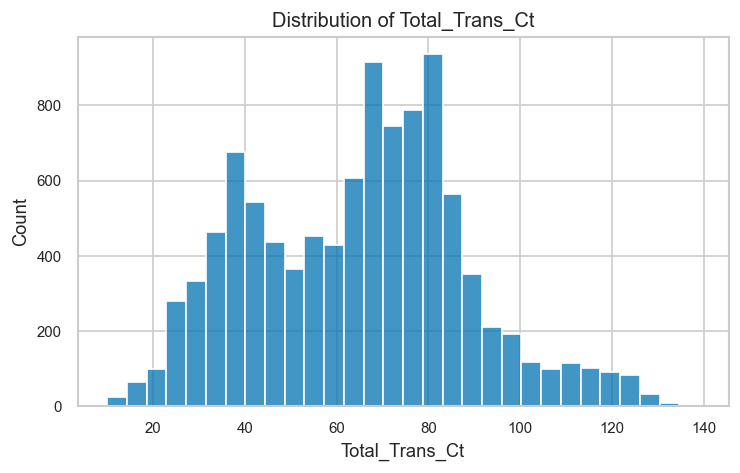

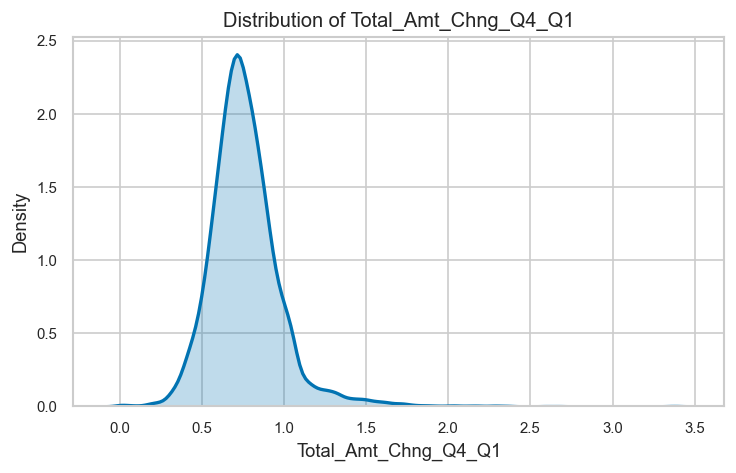

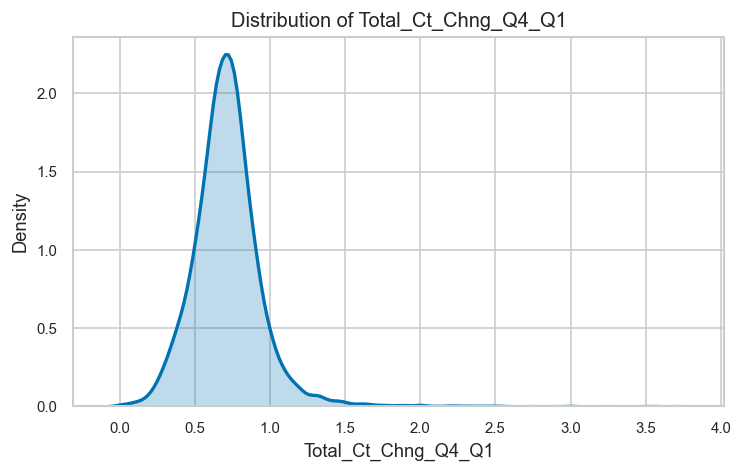

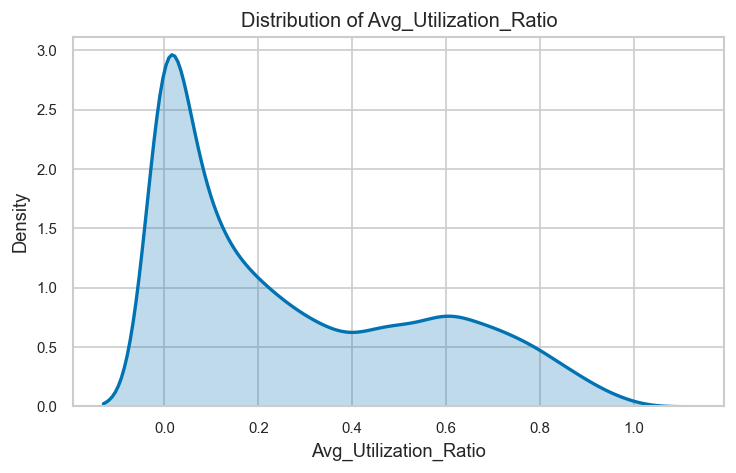

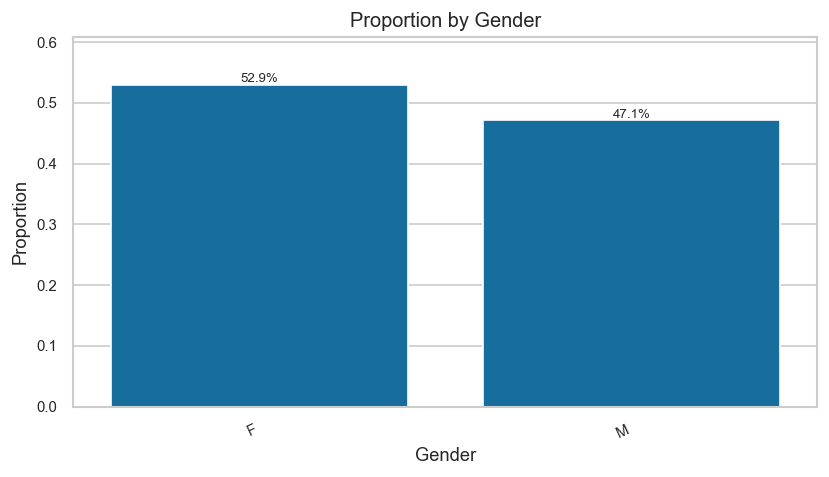

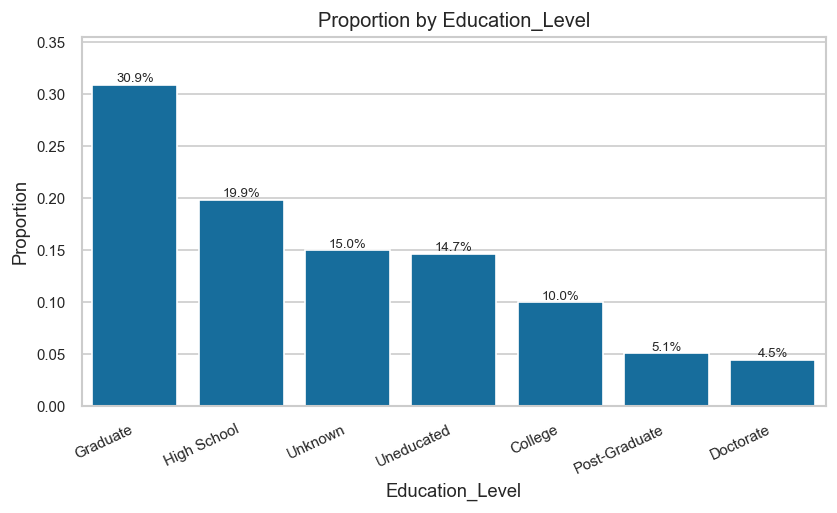

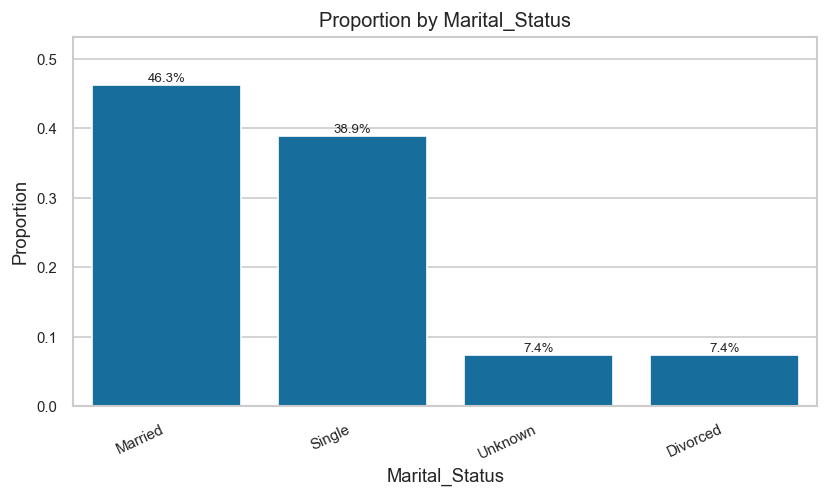

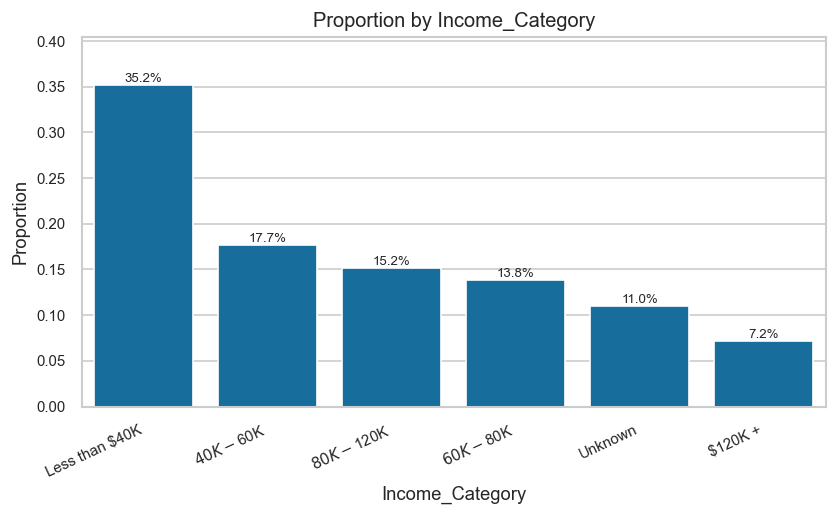

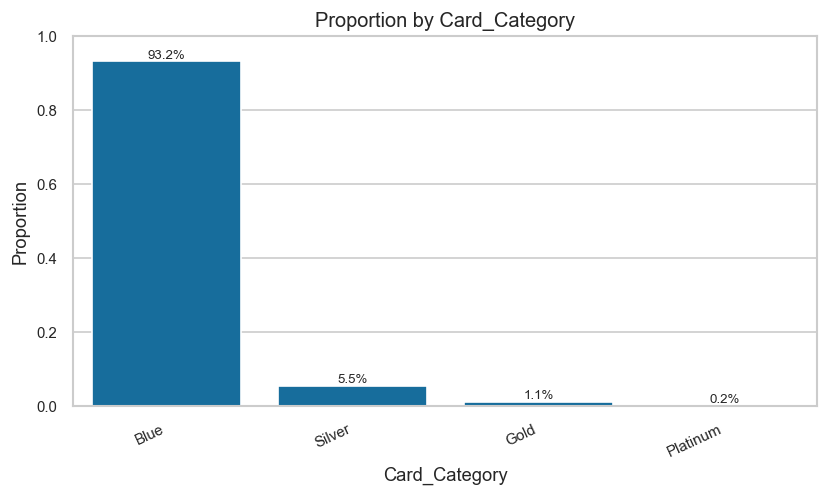

In [6]:
plot_target_distribution(df_full)
plt.show()
plt.close()

for col in NUMERICAL_COLUMNS:
    plot_univariate_numeric(df, col)
    plt.show()
    plt.close()

for col in CATEGORICAL_COLUMNS:
    plot_univariate_categorical(df, col)
    plt.show()
    plt.close()

**Observation:** Transaction, inactivity, and utilization distributions are skewed — many customers show low activity with a long tail.

**Observation:** Card tier and income category are imbalanced (many Blue / mid-income cards).

*Hypotheses below are associative only, not causal.*

## 4. Bivariate Analysis (vs churn)

C:\Users\Windows\Documents\Repo Folder\bank-churners-cursor-bootcamp\src\eda_viz.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=CHURN_COLUMN, y=column, ax=ax, palette=SEABORN_PALETTE)
C:\Users\Windows\Documents\Repo Folder\bank-churners-cursor-bootcamp\src\eda_viz.py:134: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Existing", "Churned"])


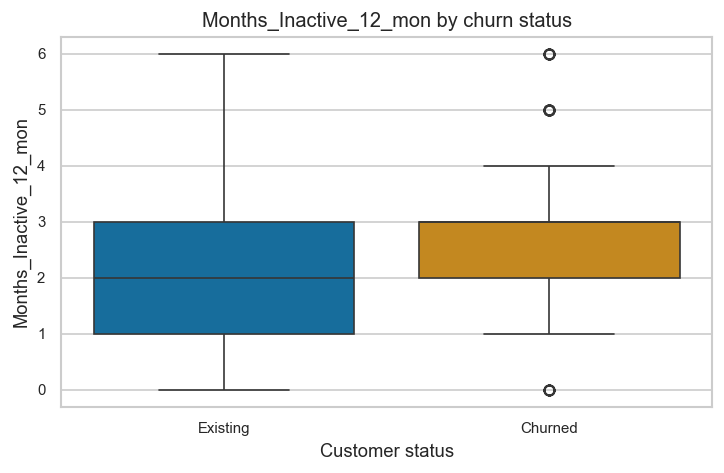

C:\Users\Windows\Documents\Repo Folder\bank-churners-cursor-bootcamp\src\eda_viz.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=CHURN_COLUMN, y=column, ax=ax, palette=SEABORN_PALETTE)
C:\Users\Windows\Documents\Repo Folder\bank-churners-cursor-bootcamp\src\eda_viz.py:134: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Existing", "Churned"])


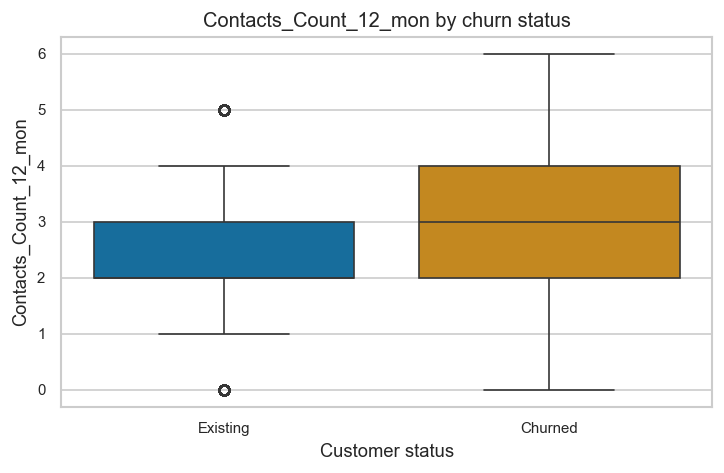

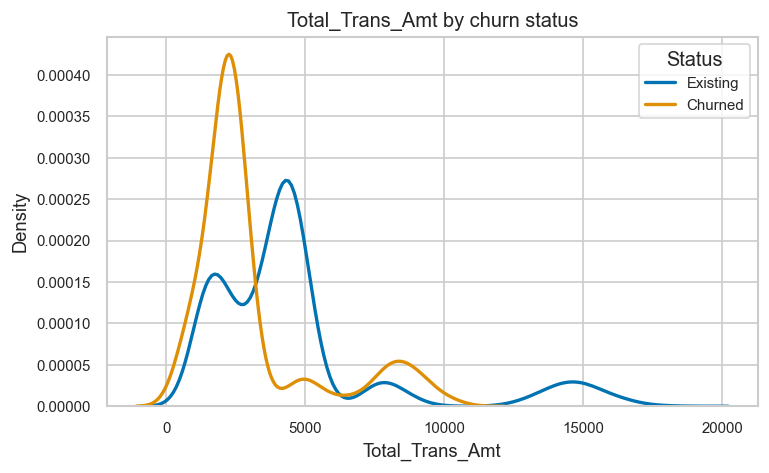

C:\Users\Windows\Documents\Repo Folder\bank-churners-cursor-bootcamp\src\eda_viz.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=CHURN_COLUMN, y=column, ax=ax, palette=SEABORN_PALETTE)
C:\Users\Windows\Documents\Repo Folder\bank-churners-cursor-bootcamp\src\eda_viz.py:134: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Existing", "Churned"])


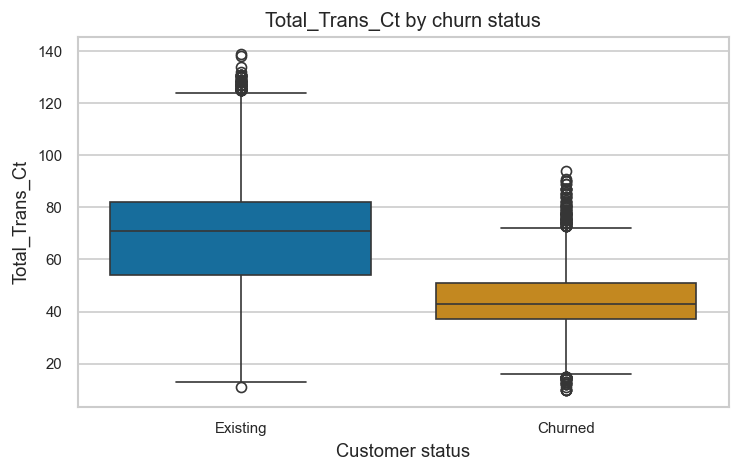

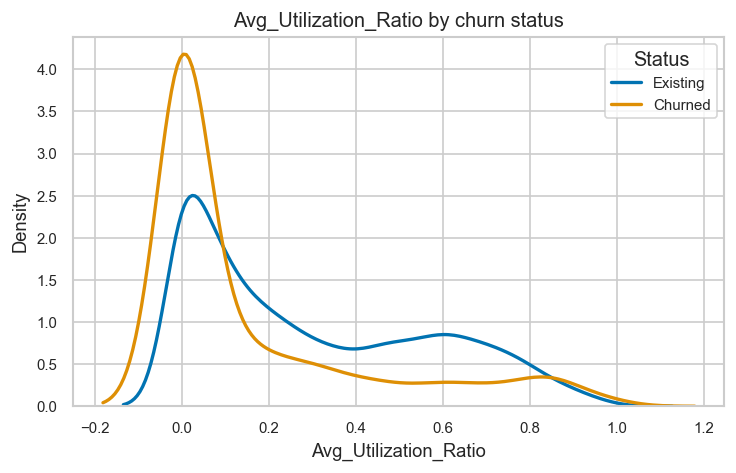

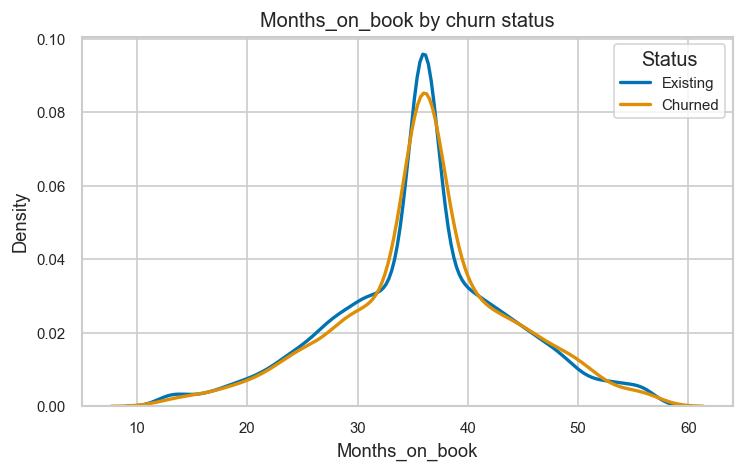

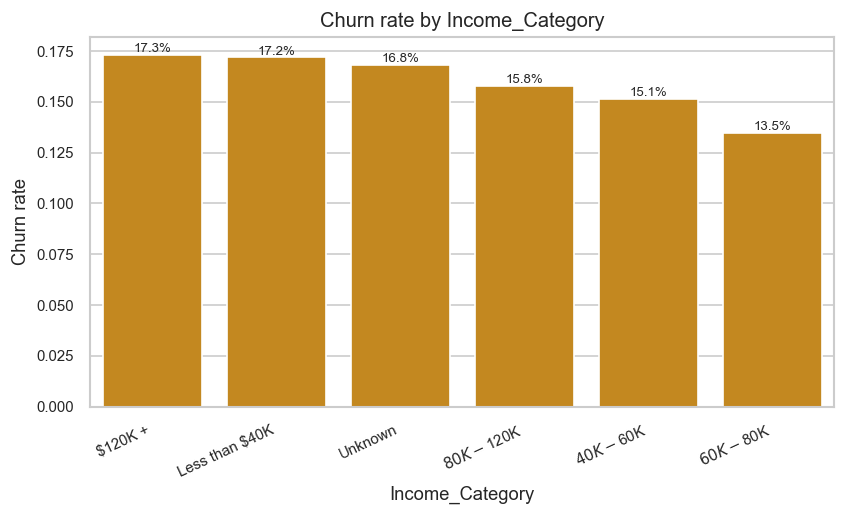

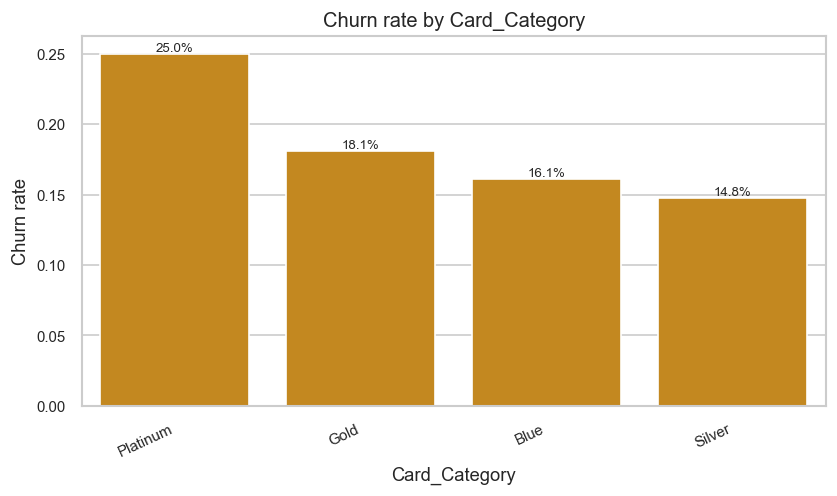

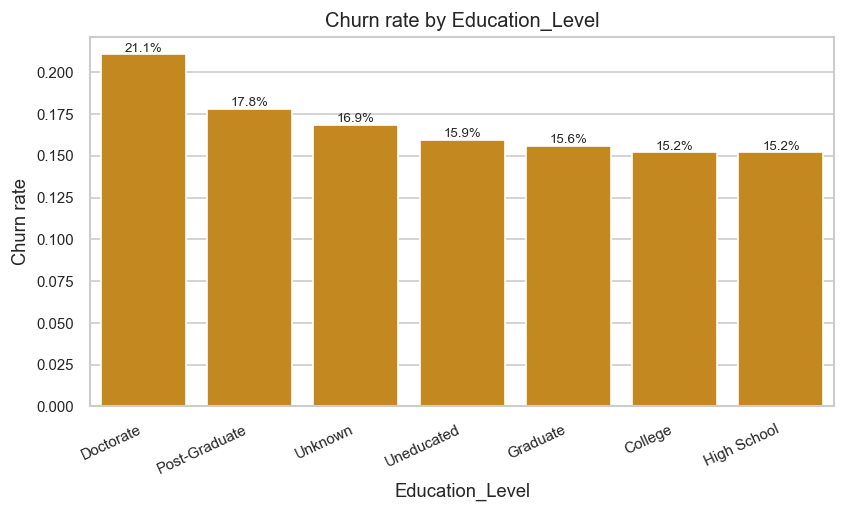

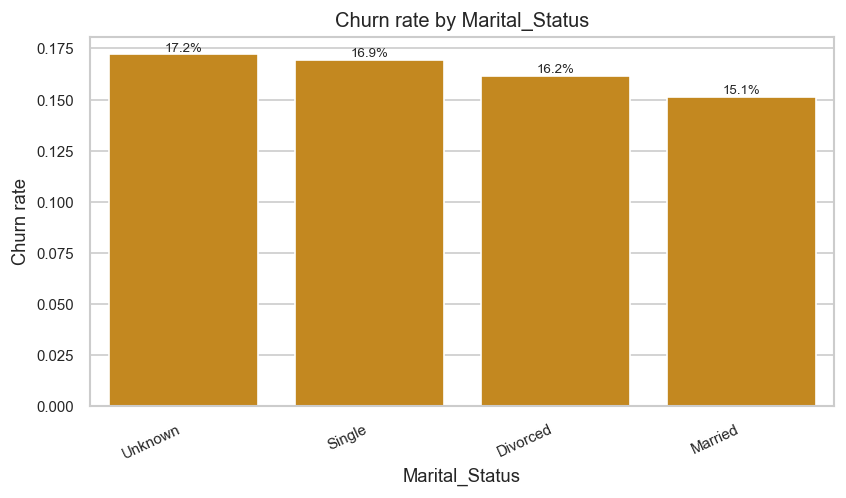

In [7]:
for col in BIVARIATE_NUMERICAL:
    plot_bivariate_numeric(df, col)
    plt.show()
    plt.close()

for col in BIVARIATE_CATEGORICAL:
    plot_bivariate_categorical(df, col)
    plt.show()
    plt.close()

**Observation:** Churned customers tend to show higher months inactive, more contacts, lower transaction amounts/counts, and different utilization patterns than existing customers in the plots above.

**Observation:** Churn rates vary by income, card category, education, and marital status segments.

**Hypothesis:** Behavioral decline (inactivity, lower transactions) may precede attrition — correlation only.

## 5. Correlation Analysis

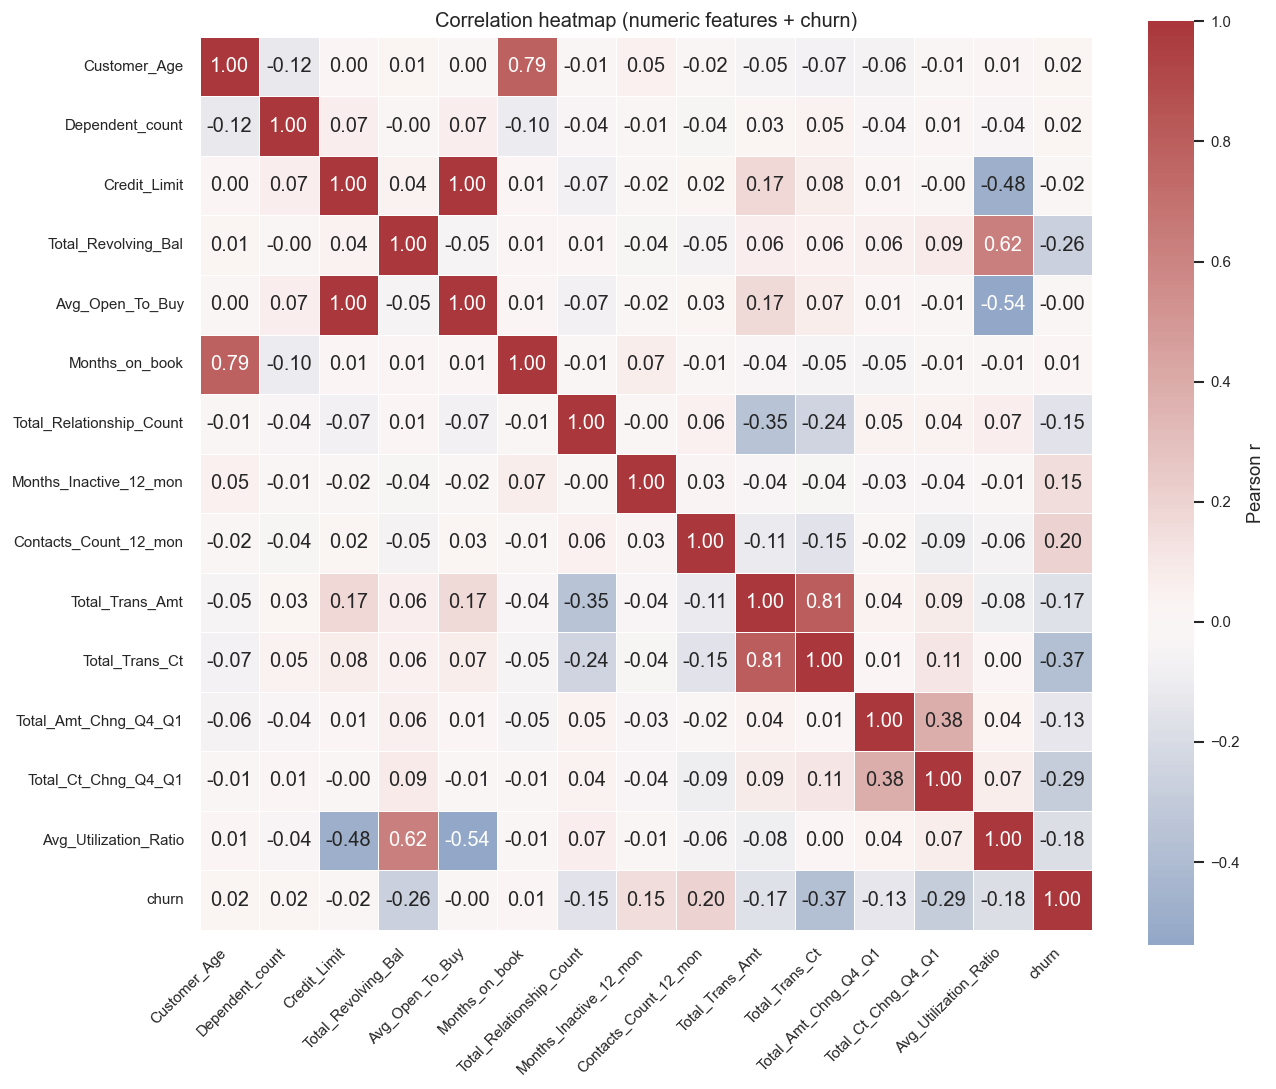

In [8]:
numeric_for_corr = [c for c in NUMERICAL_COLUMNS if c in df.columns]
plot_correlation_heatmap(df, list(numeric_for_corr))
plt.show()
plt.close()
# Confirm leakage / ID not in correlation matrix
assert not any(c in numeric_for_corr for c in LEAKAGE_COLUMNS)
assert ID_COLUMN not in numeric_for_corr

**Observation:** `Avg_Open_To_Buy`, `Credit_Limit`, and `Total_Revolving_Bal` are highly correlated — multicollinearity risk for linear models.

**Observation:** `churn` correlates most strongly with inactivity, contacts, and transaction features in this snapshot (see heatmap).

**Limitation:** Correlation ≠ causation; relationships may reflect selection or unmeasured factors.

## 6. Key Insights

### Churn rate
- About **16%** of customers attrited in this sample (class imbalance).

### Likely churn signals (associative)
- Higher `Months_Inactive_12_mon`, `Contacts_Count_12_mon`
- Lower `Total_Trans_Amt`, `Total_Trans_Ct`, change metrics
- Higher `Avg_Utilization_Ratio` / balance patterns (see bivariate charts)

### Data quality issues
- `"Unknown"` in `Education_Level`, `Income_Category`, `Marital_Status`
- Skewed numerics and IQR outliers on spend/utilization
- No duplicate IDs expected; verify if any appear

### Variables to exclude from modeling
- `CLIENTNUM` (identifier)
- Both `Naive_Bayes_Classifier_*` columns if present (leakage)
- `Attrition_Flag` (target); use binary `churn` instead

### Candidate features for modeling
- Behavioral: `Months_Inactive_12_mon`, `Contacts_Count_12_mon`, `Total_Trans_Amt`, `Total_Trans_Ct`, `Total_Amt_Chng_Q4_Q1`, `Total_Ct_Chng_Q4_Q1`, `Avg_Utilization_Ratio`, `Total_Revolving_Bal`
- Profile/relationship: `Customer_Age`, `Months_on_book`, `Total_Relationship_Count`, `Credit_Limit`, `Income_Category`, `Card_Category`, `Education_Level`, `Gender`, `Marital_Status`, `Dependent_count`

### Feature engineering decisions (for modeling)
| Topic | Decision |
|-------|----------|
| Unknown categories | Keep as explicit level or impute after EDA review; do not treat as NaN |
| Ordinal (`Income_Category`, `Education_Level`, `Card_Category`) | Map with orders starting at 1 (see `ORDINAL_MAPPINGS` in `churn_config.py`) |
| Nominal (`Gender`, `Marital_Status`) | `N-1` dummy encoding |
| `Dependent_count` | Integer numeric feature |
| Scaling | Consider for linear models; tree models less sensitive |
| Outliers | Document IQR flags; winsorize only if validation supports |
| Multicollinearity | Watch credit/limit/balance/utilization cluster |

### Ordinal vs nominal
- **Ordinal:** Income_Category, Education_Level, Card_Category
- **Nominal (N-1 dummies):** Gender, Marital_Status

### Limitations
- Snapshot data; no time-to-event analysis
- Patterns are correlational, not proof of causation


In [9]:
saved = sorted(FIGURES_DIR.glob("*.png"))
print(f"Saved {len(saved)} figures to {FIGURES_DIR}")
assert len(saved) >= 20, f"Expected >= 20 figures, got {len(saved)}"
saved[:5], "...", saved[-3:]

Saved 31 figures to C:\Users\Windows\Documents\Repo Folder\bank-churners-cursor-bootcamp\reports\figures


([WindowsPath('C:/Users/Windows/Documents/Repo Folder/bank-churners-cursor-bootcamp/reports/figures/01_target_distribution.png'),
  WindowsPath('C:/Users/Windows/Documents/Repo Folder/bank-churners-cursor-bootcamp/reports/figures/02_uni_customer_age.png'),
  WindowsPath('C:/Users/Windows/Documents/Repo Folder/bank-churners-cursor-bootcamp/reports/figures/03_uni_dependent_count.png'),
  WindowsPath('C:/Users/Windows/Documents/Repo Folder/bank-churners-cursor-bootcamp/reports/figures/04_uni_credit_limit.png'),
  WindowsPath('C:/Users/Windows/Documents/Repo Folder/bank-churners-cursor-bootcamp/reports/figures/05_uni_total_revolving_bal.png')],
 '...',
 [WindowsPath('C:/Users/Windows/Documents/Repo Folder/bank-churners-cursor-bootcamp/reports/figures/29_bivar_education_level_churn_rate.png'),
  WindowsPath('C:/Users/Windows/Documents/Repo Folder/bank-churners-cursor-bootcamp/reports/figures/30_bivar_marital_status_churn_rate.png'),
  WindowsPath('C:/Users/Windows/Documents/Repo Folder/bank